In [1]:
pip install pandas scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


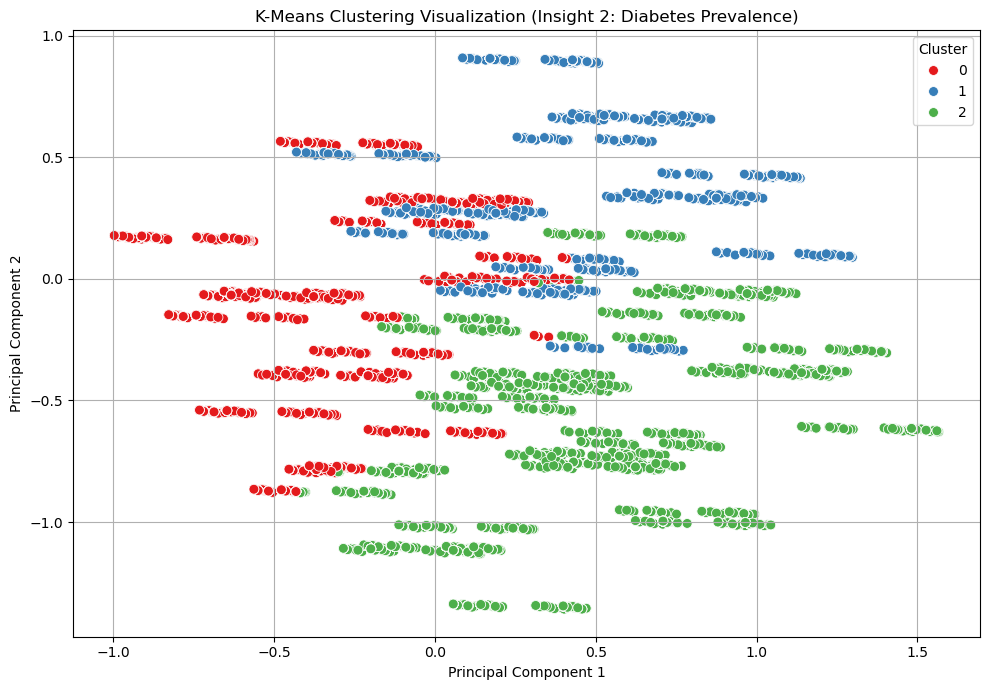

In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (make sure dmfinal.csv is in the same directory or provide full path)
df = pd.read_csv("dmfinal.csv")

# Select 10 relevant columns for Insight 2
selected_columns = [
    'HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity',
    'Fruits', 'Veggies', 'GenHlth', 'Age', 'Income'
]
df_selected = df[selected_columns]

# Normalize the data using Min-Max scaling
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_selected)

# Reduce dimensionality to 2 principal components for plotting
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Apply K-Means clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

# Create DataFrame for PCA and cluster labels
pca_df = pd.DataFrame(df_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters

# Plotting the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="Set1", s=50)
plt.title("K-Means Clustering Visualization (Insight 2: Diabetes Prevalence)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


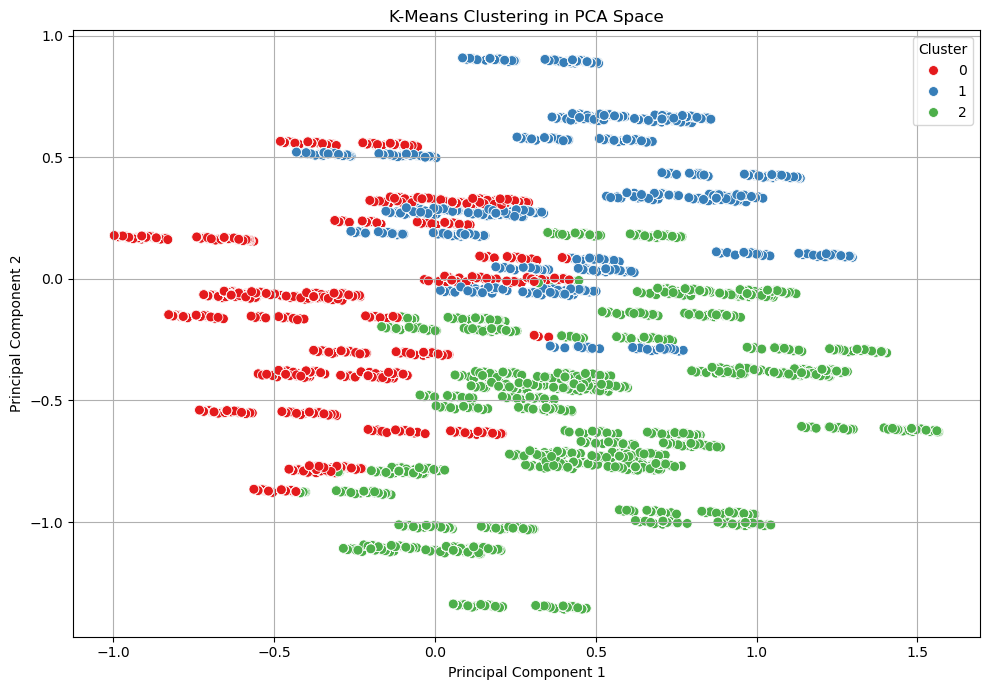

C:\Users\User\AppData\Local\Temp\ipykernel_6524\3025984662.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="Cluster", y="Prevalence (%)", palette="Set2")


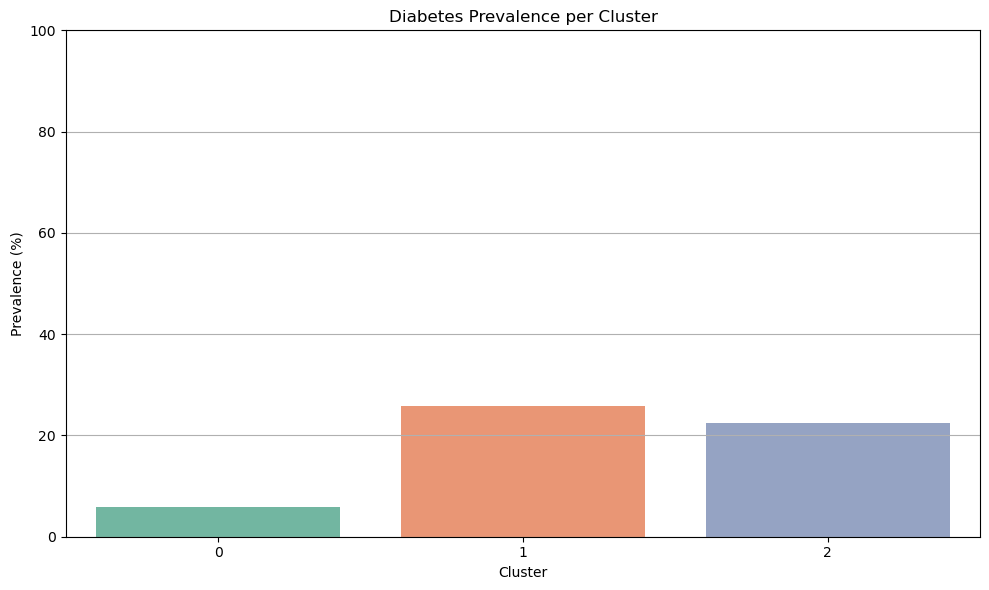

   Cluster  Count  Total  Prevalence (%)
0        0  92400   5425        5.871212
1        1  53919  13949       25.870287
2        2  55930  12519       22.383336


In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("dmfinal.csv")

# Select relevant columns + diabetes target
selected_columns = [
    'HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity',
    'Fruits', 'Veggies', 'GenHlth', 'Age', 'Income'
]
features = df[selected_columns]
target = df['Diabetes_012']  # 0 = No diabetes, 1 = Diabetes

# Normalize features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# PCA for 2D visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

# Create DataFrame for visualization
df_clustered = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
df_clustered["Cluster"] = clusters
df_clustered["Diabetes_012"] = target.values

# ---------- PLOT 1: PCA Clustering Result ----------
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_clustered, x="PC1", y="PC2", hue="Cluster", palette="Set1", s=50)
plt.title("K-Means Clustering in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# ---------- PLOT 2: Diabetes Prevalence by Cluster ----------
# Compute metrics per cluster
summary = df_clustered.groupby("Cluster").agg(
    Count=("Diabetes_012", "count"),
    Total=("Diabetes_012", "sum")
).reset_index()
summary["Prevalence (%)"] = (summary["Total"] / summary["Count"]) * 100

# Bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=summary, x="Cluster", y="Prevalence (%)", palette="Set2")
plt.title("Diabetes Prevalence per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Prevalence (%)")
plt.ylim(0, 100)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Optionally print the summary table
print(summary)


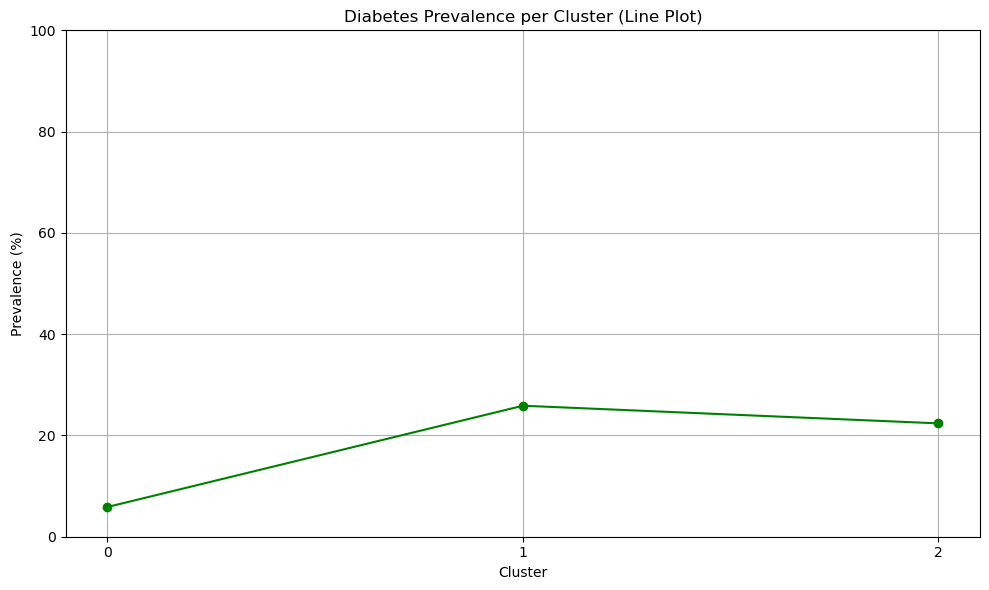

In [9]:
# ---------- PLOT 2 (Modified): Line Plot for Diabetes Prevalence ----------
plt.figure(figsize=(10, 6))
plt.plot(summary["Cluster"], summary["Prevalence (%)"], marker='o', linestyle='-', color='green')
plt.title("Diabetes Prevalence per Cluster (Line Plot)")
plt.xlabel("Cluster")
plt.ylabel("Prevalence (%)")
plt.ylim(0, 100)
plt.grid(True)
plt.xticks(summary["Cluster"])
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_6524\917444976.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["Diabetes_012"] = df["Diabetes_012"]


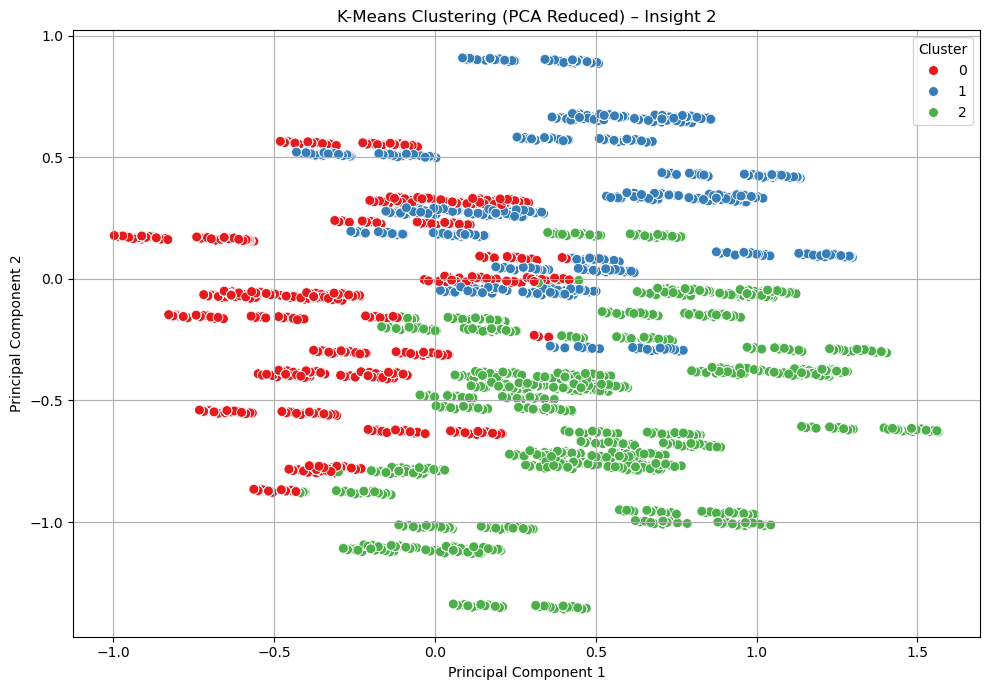

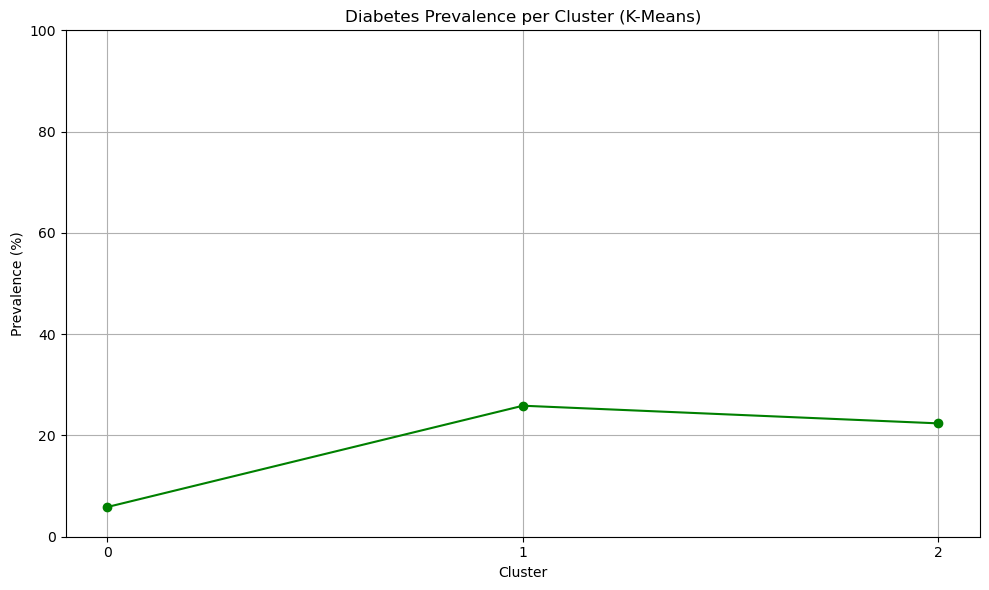

   Cluster  Count  Total  Prevalence (%)
0        0  92400   5425        5.871212
1        1  53919  13949       25.870287
2        2  55930  12519       22.383336


In [15]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load your dataset
df = pd.read_csv("dmfinal.csv")  # Replace with your path if needed

# Step 2: Select 10 relevant columns
selected_columns = [
    'HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity',
    'Fruits', 'Veggies', 'GenHlth', 'Age', 'Income'
]
df_selected = df[selected_columns]

# Optional: include the target if you want to calculate diabetes prevalence
df_selected["Diabetes_012"] = df["Diabetes_012"]

# Step 3: Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_selected[selected_columns])

# Step 4: Reduce dimensionality to 2D using PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Step 5: Apply K-Means clustering (change k as needed)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Step 6: Create DataFrame for plotting and analysis
pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters
pca_df["Diabetes_012"] = df_selected["Diabetes_012"].values

# Step 7: Scatter Plot (PCA Visualization)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="Set1", s=50)
plt.title("K-Means Clustering (PCA Reduced) – Insight 2")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# Step 8: Calculate and Plot Diabetes Prevalence per Cluster
summary = pca_df.groupby("Cluster").agg(
    Count=("Diabetes_012", "count"),
    Total=("Diabetes_012", "sum")
).reset_index()
summary["Prevalence (%)"] = (summary["Total"] / summary["Count"]) * 100

# Line plot for prevalence
plt.figure(figsize=(10, 6))
plt.plot(summary["Cluster"], summary["Prevalence (%)"], marker='o', linestyle='-', color='green')
plt.title("Diabetes Prevalence per Cluster (K-Means)")
plt.xlabel("Cluster")
plt.ylabel("Prevalence (%)")
plt.ylim(0, 100)
plt.grid(True)
plt.xticks(summary["Cluster"])
plt.tight_layout()
plt.show()

# Print summary table
print(summary)


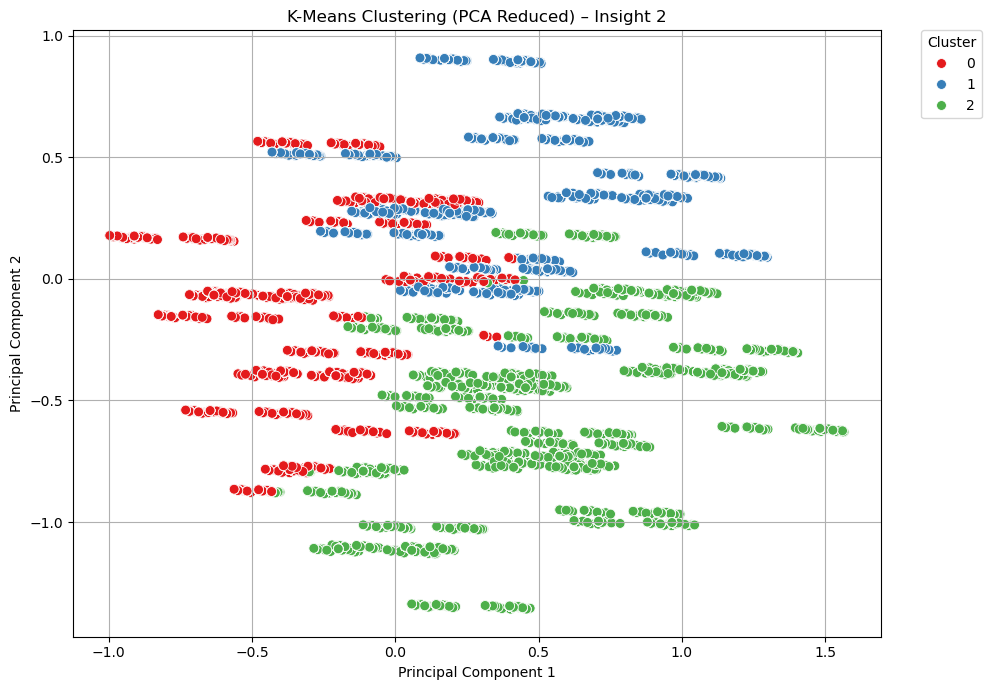

In [17]:
# PCA Scatter Plot with legend bar at the right
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="Set1", s=50)

# Adjust legend placement to the right side
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("K-Means Clustering (PCA Reduced) – Insight 2")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()


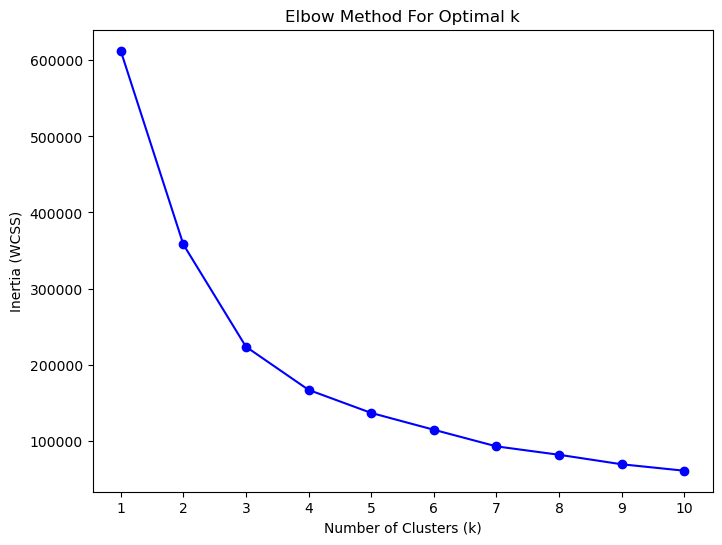

In [27]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('dmfinal.csv')  # Replace with your actual file

# Select your specified columns
columns = ['HighBP', 'HighChol', 'BMI', 'Smoker', 
           'PhysActivity', 'Fruits', 'Veggies', 
           'GenHlth', 'Age', 'Income']

data = df[columns].dropna()

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# (Optional) Reduce with PCA first (can also use raw data)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Elbow Method
inertia = []
K_range = range(1, 11)  # Try k = 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method For Optimal k')
plt.xticks(K_range)
plt.show()


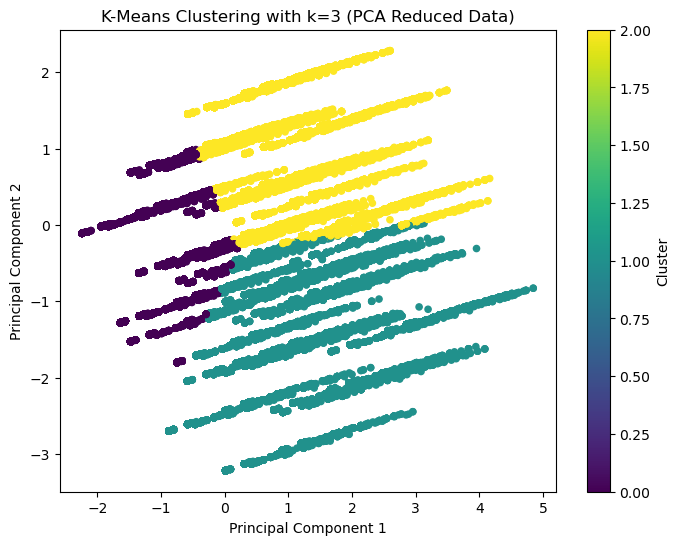

In [29]:
# Example: use k=3 based on elbow method
optimal_k = 3  # Replace with your chosen k

# Run K-Means on the same data (e.g., PCA reduced)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(pca_data)  # Use the data you did elbow on!

# Add the cluster labels to your DataFrame if you want
df['Cluster'] = clusters

# Plot the final clustering result (PCA scatter plot)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=clusters,
    cmap='viridis',
    s=20
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'K-Means Clustering with k={optimal_k} (PCA Reduced Data)')
plt.show()


In [35]:
import pandas as pd

# Total number of samples
total = len(df)

# Group by Cluster and count
cluster_counts = df['Cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', 'Count']

# Add Total column
cluster_counts['Total'] = total

# Add Prevalence (%) column
cluster_counts['Prevalence (%)'] = (cluster_counts['Count'] / total) * 100

print(cluster_counts)


   Cluster  Count   Total  Prevalence (%)
0        0  90365  202249       44.680073
1        1  41868  202249       20.701215
2        2  70016  202249       34.618713


In [39]:
import pandas as pd

# Example: your DataFrame now has a 'Cluster' column
# df['Cluster'] = clusters

# Count number of rows in each cluster
cluster_counts = df['Cluster'].value_counts().sort_index()

# Calculate total rows
total_rows = len(df)

# Calculate prevalence (%) per cluster
prevalence = (cluster_counts / total_rows) * 100

# Combine into a summary table
summary = pd.DataFrame({
    'Cluster': cluster_counts.index,
    'Count': cluster_counts.values,
    'Total': total_rows,
    'Prevalence (%)': prevalence.round(2)
})

print(summary)


         Cluster  Count   Total  Prevalence (%)
Cluster                                        
0              0  90365  202249           44.68
1              1  41868  202249           20.70
2              2  70016  202249           34.62


In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Standardize your selected features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[columns].dropna())

# PCA reduction
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Run K-Means with your chosen k (e.g., k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_data)

# Add cluster labels to your DataFrame
df['Cluster'] = clusters


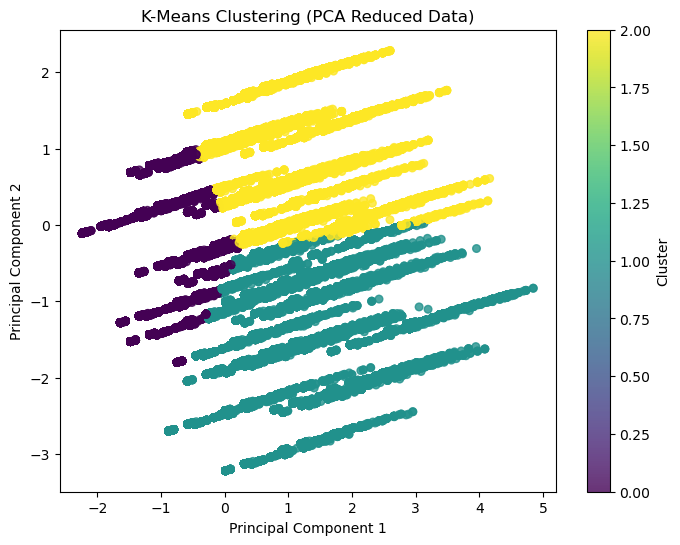

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=clusters,
    cmap='viridis',
    s=30,  # Increase dot size for clarity
    alpha=0.8  # Slight transparency if overlapping
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (PCA Reduced Data)')
plt.show()


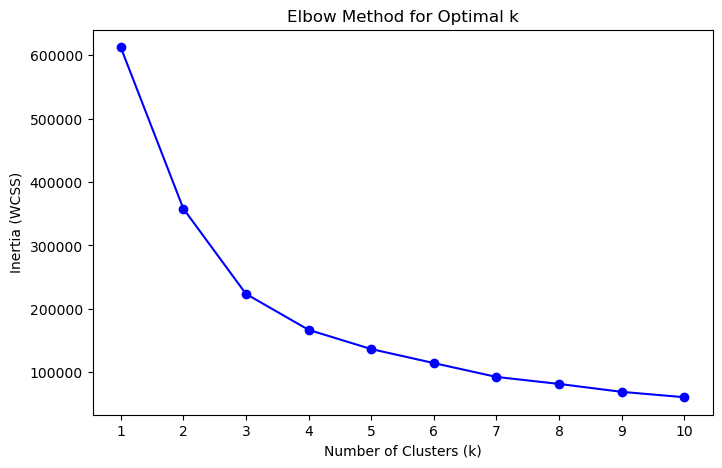

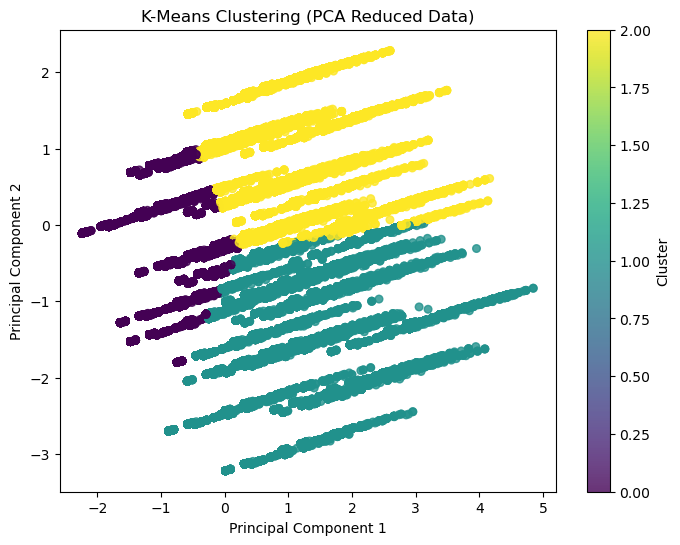

,Cluster,Count,Total,Prevalence (%)
0,0,4738,90365,5.24
1,1,7921,41868,18.92
2,2,19234,70016,27.47


In [53]:
# ===========================================
# 1️⃣ Libraries
# ===========================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: For pretty tables in notebook
from IPython.display import display

# ===========================================
# 2️⃣ Load your dataset
# ===========================================
# Replace with your CSV file
df = pd.read_csv('dmfinal.csv')

# ===========================================
# 3️⃣ Select your 10 features
# ===========================================
columns = [
    'HighBP', 'HighChol', 'BMI', 'Smoker', 
    'PhysActivity', 'Fruits', 'Veggies', 
    'GenHlth', 'Age', 'Income'
]

# If you have diabetes status column:
# Make sure it's in the dataframe too!
target_col = 'Diabetes_012'  # Replace with your actual diabetes column name

# Drop missing values
df = df[columns + [target_col]].dropna()

# ===========================================
# 4️⃣ Standardize
# ===========================================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[columns])

# ===========================================
# 5️⃣ PCA (2 components)
# ===========================================
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# ===========================================
# 6️⃣ Elbow method (optional)
# ===========================================
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.show()

# ===========================================
# 7️⃣ Final K-Means Clustering
# ===========================================
# Replace k with your chosen number from elbow plot
optimal_k = 3  

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(pca_data)

# Add cluster labels to DataFrame
df['Cluster'] = clusters

# ===========================================
# 8️⃣ Visualize Clusters (PCA scatter plot)
# ===========================================
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_data[:, 0], pca_data[:, 1],
    c=clusters, cmap='viridis', s=30, alpha=0.8
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (PCA Reduced Data)')
plt.show()

# ===========================================
# 9️⃣ Create Summary Table
# ===========================================
summary = df.groupby('Cluster').agg(
    Count=(target_col, 'sum'),        # Diabetic cases per cluster
    Total=(target_col, 'count')       # Total cases per cluster
).reset_index()

summary['Prevalence (%)'] = (summary['Count'] / summary['Total']) * 100
summary['Prevalence (%)'] = summary['Prevalence (%)'].round(2)

# Display summary table
display(summary)

# ===========================================
# 🔟 Save summary table if needed
# ===========================================
summary.to_csv('cluster_summary.csv', index=False)


In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from IPython.display import display


In [63]:
# Load your CSV
df = pd.read_csv('dmfinal.csv')

# Your selected features
columns = [
    'HighBP', 'HighChol', 'BMI', 'Smoker', 
    'PhysActivity', 'Fruits', 'Veggies', 
    'GenHlth', 'Age', 'Income'
]

# If you have a diabetes column
target_col = 'Diabetes_012'  # Replace with your actual name
df.columns = df.columns.str.strip()

# Drop missing values
df = df[columns + [target_col]].dropna()


In [65]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[columns])

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)


In [67]:
dbscan = DBSCAN(eps=0.15, min_samples=20)
clusters = dbscan.fit_predict(pca_data)

# Add to DataFrame
df['Cluster'] = clusters


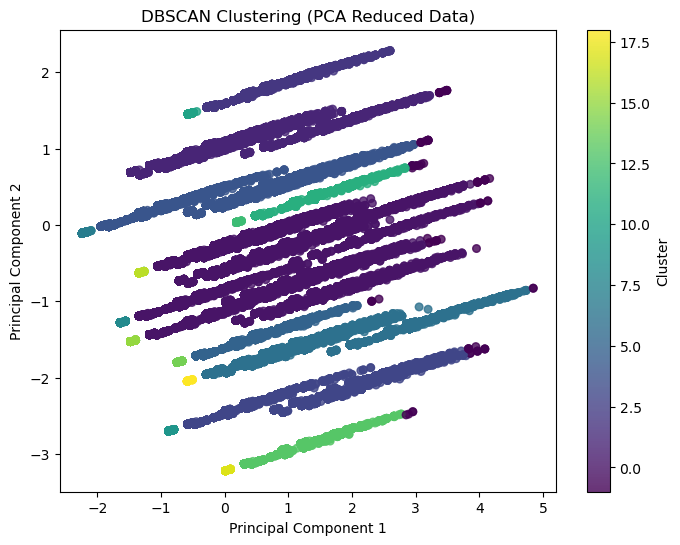

In [68]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_data[:, 0], pca_data[:, 1],
    c=clusters, cmap='viridis', s=30, alpha=0.8
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering (PCA Reduced Data)')
plt.show()


In [71]:
# Handle noise (-1) as its own cluster
summary = df.groupby('Cluster').agg(
    Count=(target_col, 'sum'),        # Diabetic cases per cluster
    Total=(target_col, 'count')       # Total cases in cluster
).reset_index()

summary['Prevalence (%)'] = (summary['Count'] / summary['Total']) * 100
summary['Prevalence (%)'] = summary['Prevalence (%)'].round(2)

display(summary)


,Cluster,Count,Total,Prevalence (%)
0,-1,38,82,46.34
1,0,9139,54166,16.87
2,1,6606,38183,17.30
3,2,5464,18863,28.97
4,3,1011,7934,12.74
5,4,5648,48296,11.69
6,5,355,4096,8.67
7,6,2303,9357,24.61
8,7,86,9805,0.88
9,8,28,2525,1.11


     Model  Cluster  Total  Diabetic  Prevalence (%)
0   DBSCAN       -1     29        11           37.93
1   DBSCAN        0   1843       213           11.56
2   DBSCAN        1   2321       322           13.87
3   DBSCAN        2   2145        69            3.22
4   DBSCAN        3   1321       345           26.12
5   DBSCAN        4   1755       291           16.58
6   DBSCAN        5     85        42           49.41
7   DBSCAN        6     35        18           51.43
8   DBSCAN        7     33         6           18.18
9   DBSCAN        8    392       134           34.18
10  DBSCAN        9     41        27           65.85
11  KMeans        0   2336       164            7.02
12  KMeans        1   3394       171            5.04
13  KMeans        2   2297       604           26.30
14  KMeans        3   1973       539           27.32


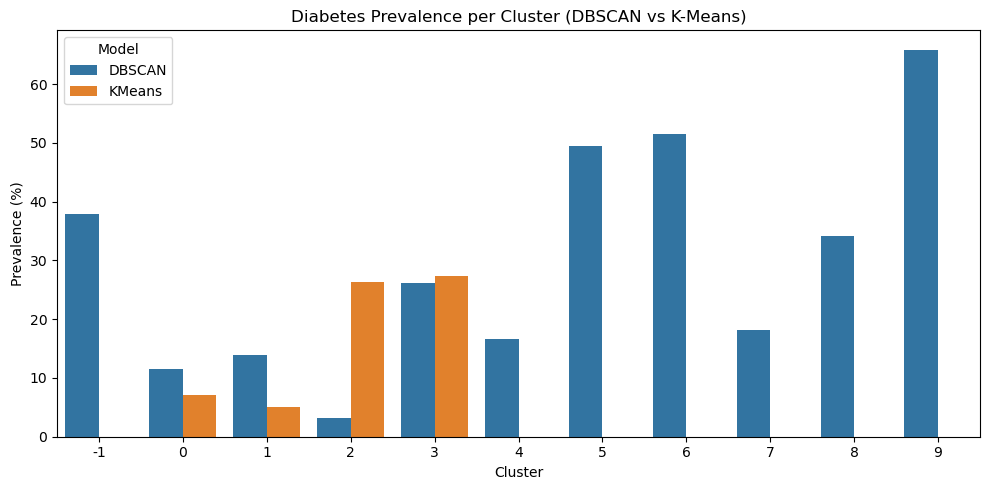

In [73]:
# --- STEP 1: Load & Preprocess ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("dmfinal.csv")
df = df[df["BMI"] <= 60]  # Remove extreme values
df = df.sample(n=10000, random_state=42)  # 🔹 sample to avoid crash

# Select risk-related features
features = ["HighBP", "HighChol", "BMI", "Smoker", "PhysActivity"]
X = df[features]
y = df["Diabetes_012"]

# --- STEP 2: Scale + Reduce Dimensions ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2D (for DBSCAN + visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- STEP 3: Clustering ---
# K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

# DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_pca)

# --- STEP 4: Compare Cluster Diabetes Prevalence ---
df_km = df.copy()
df_km["Cluster"] = kmeans_labels
df_km["Model"] = "KMeans"

df_db = df.copy()
df_db["Cluster"] = dbscan_labels
df_db["Model"] = "DBSCAN"

combined = pd.concat([df_km, df_db])
summary = combined.groupby(["Model", "Cluster"])["Diabetes_012"].agg(["count", "sum"])
summary["Prevalence (%)"] = (summary["sum"] / summary["count"] * 100).round(2)
summary = summary.rename(columns={"count": "Total", "sum": "Diabetic"})
print(summary.reset_index())

# --- STEP 5: Visual Comparison ---
summary = summary.reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x="Cluster", y="Prevalence (%)", hue="Model")
plt.title("Diabetes Prevalence per Cluster (DBSCAN vs K-Means)")
plt.xlabel("Cluster")
plt.ylabel("Prevalence (%)")
plt.tight_layout()
plt.show()